# Fully-phase arithmetic

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$This notebook shows the implementation of the Boltzmann coin $B$ using only the [phase-arithmetic approach](https://arxiv.org/abs/2210.14892). This approach minimizes the number of qubits required to implement the coin.

The fully-phase arithmetic coin acts directly on the registers $\ket{x}_a\ket{y}_b\ket{c}$, where $\ket{x}_a$ and $\ket{y}_b$ are $n$-qubit registers storing the current and proposed configurations, or a superposition of such configurations, and $\ket{c}$ is the acceptance coin register. The idea is to avoid explicitly computing $\Delta E(x,y)$ using reversible classical arithmetic. Instead, we apply a polynomial transformation of a diagonal Hamiltonian whose eigenvalues are precisely the energy differences.

The Hamiltonian of interest here is the delta-energy Hamiltonian acting on $2n$ spins. Starting from the Ising Hamiltonian $H=\sum_{i=1}^{n} h_i Z_i+\sum_{i<j}J_{ij}Z_iZ_j$, we define
$$
H_\Delta=-H^{(a)}+H^{(b)}.
$$
Notably,
$$
H_\Delta\ket{x}_a\ket{y}_b
=
\bigl(H(y)-H(x)\bigr)\ket{x}_a\ket{y}_b
=
\Delta E(x,y)\ket{x}_a\ket{y}_b .
$$

A block-encoding of the operator $H_\Delta/\alpha$ can be obtained via LCU, and from that we define the qubitized operator $W_\Delta$. Such an operator has eigenvalues $\exp(\pm i\arccos(\Delta E/\alpha))$, which can be transformed by Generalized Quantum Signal Processing (GQSP). The GQSP sequence implements a Laurent polynomial in these phases, or equivalently a Chebyshev polynomial in $x=\Delta E/\alpha$. The target amplitude is
$$
g(x) \approx \min\left\{1, \exp\left(-\frac{1}{2}\beta\alpha x\right)\right\},
$$
which is the square root of the Metropolis-Hastings acceptance probability.

**Table of contents**:

1. Summary of the resources
2. Primitives
3. Implementation
4. Error of the polynomial approximation

## Summary of the resources

The amount of resources required are

| Component | Non-Clifford depth | Total qubits |
|---|---:|---:|
| PREPARE | $28n-24$ | $6n$ |
| SELECT | $0$ | $8n$ |
| Controlled-SELECT | $\le 2n+3$ | $10n$ |
| Reflection | $14\lceil\log_2(6n-1)\rceil-13$ | $6n+2$ |
| Controlled-Reflection | $14\lceil\log_2(6n)\rceil-13$ | $6n+3$ |
| Qubitized operator | $56n-61+14\lceil\log_2(6n-1)\rceil$ | $8n+2$ |
| Controlled-Qubitized operator | $\le 58n-58+14\lceil\log_2(6n)\rceil$ | $10n+2$ |
| FullyPhaseArithmetic | $\le 3d\left(58n-58+14\lceil\log_2(6n)\rceil\right)+3(2d+1)$ | $10n+2$ |

Let $L:=\log_2(\varepsilon_{\mathrm{ops}}^{-1})$. A practical degree estimate is
$$
d = 2 + \max \left\{ \sqrt{\frac{\beta \alpha}{2}L} + L, \frac{\alpha}{w}L \right\},
$$
where $w$ is the excluded window around the kink at $\Delta E=0$. The first term controls the positive exponential branch, while the second controls the resolution of the window boundary.

To obtain a more readable resource estimate in a reasonable regime, we set the following simplifications:

* Substitute $\log_2(6n-1)$ with $\log_2(6n)$.
* Find an upper bound for $\log_2(6n)$ in the form $c\times n$ holding for all $n\ge 10$; here $\log_2(6n)\le n$ is enough.
* Set $\log_2\varepsilon_{\mathrm{ops}}^{-1}=16$, replace the conservative LCU scale by the empirical spectral scale $B\simeq 2n$, and take $w=1$. This gives $d=2+4\max\{\sqrt{\beta n},8n\}\approx 2+32n$, assuming the window term dominates.

With these substitutions, the table becomes

| Component | Non-Clifford depth | Total qubits |
|---|---:|---:|
| PREPARE | $28n-24$ | $6n$ |
| SELECT | $0$ | $8n$ |
| Controlled-SELECT | $\le 2n+3$ | $10n$ |
| Reflection | $\le 14n-13$ | $6n+2$ |
| Controlled-Reflection | $\le 14n-13$ | $6n+3$ |
| Qubitized operator | $\le 70n-61$ | $8n+2$ |
| Controlled-Qubitized operator | $\le 72n-58$ | $10n+2$ |
| FullyPhaseArithmetic | $\le 6912n^2-4944n-333$ | $10n+2$ |

Thus, in this regime, the fully-phase arithmetic coin uses $O(n)$ qubits and $O(n^2)$ non-Clifford depth, with the dominant contribution coming from the $O(n)$-degree GQSP sequence applied to an $O(n)$-depth controlled qubitized operator.

## Primitives

While some gates are present as primitives in Qiskit, we want to have full control over how each gate is synthesized into the desired gate set. For that reason, we explicitly state the synthesis whenever it may be ambiguous. Among the primitives used here are controlled rotations around $Y$ and Givens rotations.

#### Controlled-RY($\theta$)

The controlled-RY $CRY(\theta)^{c}_{t}$, with control qubit $c$ and target qubit $t$, can be decomposed as $CRY(\theta)^{c}_{t}={R}_Y(\theta/2)_t\;CX^{c}_{t}\;{R}_Y(-\theta/2)_t\;CX^{c}_{t}$, where ${R}_Y(\varphi)=S^\dagger H\,RZ(\varphi)\,HS$. It therefore has non-Clifford depth $2$, one layer for each $RZ$ rotation.

<img src="gates/cry.png" style="width: 750px">


#### Doubly-controlled-RY($\theta$)

The doubly-controlled-RY $CCRY(\theta)^{c_1,c_2}_{t}$ can be decomposed as $CCRY(\theta)^{c_1,c_2}_{t}={R}_Y(\theta/2)_t\;CCX^{c_1,c_2}_{t}\;{R}_Y(-\theta/2)_t\;CCX^{c_1,c_2}_{t}$. It therefore has non-Clifford depth $4$: two layers from the $RZ$ rotations and two layers from the Toffoli gates.

<img src="gates/ccry.png" style="width: 750px">

#### Givens Rotation and Controlled-Givens Rotation

The Givens rotation $G(\theta)_{a,b}$ is the number-preserving two-qubit rotation defined, in the basis $\{\ket{00},\ket{10},\ket{01},\ket{11}\}$, as 
$$G(\theta)=\begin{pmatrix}1&0&0&0\\0&\cos\theta&-\sin\theta&0\\0&\sin\theta&\cos\theta&0\\0&0&0&1\end{pmatrix}.$$

Given two nonnegative weights $L$ and $R$, we choose $\cos\theta=\sqrt{L/(L+R)}$ and $\sin\theta=\sqrt{R/(L+R)}$, so that 

$$G(\theta)_{a,b}\ket{10}_{a,b}=\sqrt{\frac{L}{L+R}}\ket{10}_{a,b}+\sqrt{\frac{R}{L+R}}\ket{01}_{a,b}.$$

In our implementation, $G(\theta)_{a,b}$ is decomposed as $CX^a_b\;CRY(-2\theta)^b_a\;CX^a_b$. Since the two CNOTs are Clifford and $CRY$ has non-Clifford depth $2$, the Givens rotation has non-Clifford depth $2$.

<img src="gates/givens.png" style="width: 250px">


The controlled-Givens rotation $CG(\theta)^c_{a,b}$ applies the same Givens rotation only when the control qubit $c$ is active. It is implemented as $CCX^{c,a}_{b}\;CCRY(-2\theta)^{c,b}_{a}\;CCX^{c,a}_{b}$. The two outer Toffoli gates each contribute one non-Clifford layer, and $CCRY$ contributes non-Clifford depth $4$. Therefore, the controlled-Givens rotation has total non-Clifford depth $6$.

<img src="gates/givens-c.png" style="width: 250px">

## Implementation

#### PREPARE operator (Delta Energy operator)

The PREPARE operator for $H_\Delta$ acts on three unary registers $\ket{z}\ket{u}\ket{v}$, each of length $2n$. The register $\ket{z}$ indexes the one-body terms, while $\ket{u}\ket{v}$ indexes the two-body terms. Its action is

$$
\mathrm{PREPARE}\ket{0^{2n}}\ket{0^{2n}}\ket{0^{2n}}
=
\frac{1}{\sqrt{\lambda}}
\left(
\sum_i \sqrt{|h_i^\Delta|}\;\ket{e_i}\ket{0}\ket{0}
+
\sum_{i<j}\sqrt{|J^\Delta_{ij}|}\;\ket{0}\ket{e_i}\ket{e_j}
\right),
$$

where $\lambda=\lambda_Z+\lambda_J$, $\lambda_Z=\sum_i |h_i^\Delta|$, and $\lambda_J=\sum_{i<j}|J^\Delta_{ij}|$.

It is implemented as follows.

1. We apply $X$ to the first qubit of the $\ket{z}$ register, obtaining $\ket{e_1}\ket{0}\ket{0}$.

2. We apply a Givens rotation $G(\lambda_Z,\lambda_J)_{z_1,u_1}$, obtaining $\sqrt{\lambda_Z/\lambda}\ket{e_1}\ket{0}\ket{0}+\sqrt{\lambda_J/\lambda}\ket{0}\ket{e_1}\ket{0}$. This separates the one-body and two-body branches.

3. We apply two unary ladders.

   * On the $\ket{z}$ register, we apply $\prod_{k=1}^{2n-1}G\left(|h_k^\Delta|,\sum_{\ell=k+1}^{2n}|h_\ell^\Delta|\right)_{z_k,z_{k+1}}$, which maps $\ket{e_1}_z$ to $\sum_i\sqrt{|h_i^\Delta|/\lambda_Z}\ket{e_i}_z$.
   * On the $\ket{u}$ register, define $R_i=\sum_{j>i}|J^\Delta_{ij}|$ and apply $\prod_{k=1}^{2n-1}G\left(R_k,\sum_{\ell=k+1}^{2n}R_\ell\right)_{u_k,u_{k+1}}$, which maps $\ket{e_1}_u$ to $\sum_i\sqrt{R_i/\lambda_J}\ket{e_i}_u$. Here, $R_i$ is the weight of the $i$-th row.

4. We initialize the second endpoint by applying $c\text{-}X^{\{u_i\}}_{v_{i+1}}$ for $i=1,\dots,2n-1$. Thus, if the first endpoint is $i$, the second endpoint starts at $j=i+1$. This is the row preparation routine.

5. We spread the second endpoint over all $j>i$. Let $T_{i,j}=\sum_{\ell=j}^{2n}|J^\Delta_{i\ell}|$. For each $i<j<2n$, we apply the controlled Givens rotation $c\text{-}G^{\{u_i\}}_{v_j,v_{j+1}}\left(|J^\Delta_{ij}|,T_{i,j+1}\right)$. For fixed $i$, this maps $\ket{e_{i+1}}_v$ to $\sum_{j>i}\sqrt{|J^\Delta_{ij}|/R_i}\ket{e_j}_v$. This is the column preparation routine.

The non-Clifford depth for the procedure is $0+2+\max\{2(2n-1),2(2n-1)\}+0+6\cdot 2\cdot(2n-2)=28n-24$ after scheduling the independent unary ladders and controlled-Givens layers in parallel. The implementation uses $3(2n)=6n$ qubits, which are all auxiliary to the calculation.

#### SELECT (Delta Energy operator)

The SELECT operator acts on the three unary selection registers $\ket{z}\ket{u}\ket{v}$ and on the system registers $\ket{x}_a\ket{y}_b$, which together have length $2n$. On the valid unary labels loaded by PREPARE, SELECT acts as

$$
\mathrm{SELECT}\left(\ket{e_i}_z\ket{0}_u\ket{0}_v(\ket{x}_a\ket{y}_b)\right)
=
\ket{e_i}_z\ket{0}_u\ket{0}_v
\left(\operatorname{sgn}(h_i^\Delta)Z_i(\ket{x}_a\ket{y}_b)\right),
$$

and

$$
\mathrm{SELECT}\left(\ket{0}_z\ket{e_i}_u\ket{e_j}_v(\ket{x}_a\ket{y}_b)\right)
=
\ket{0}_z\ket{e_i}_u\ket{e_j}_v
\left(\operatorname{sgn}(J^\Delta_{ij})Z_iZ_j(\ket{x}_a\ket{y}_b)\right).
$$

Note that the PREPARE primitive loads the unsigned weight of each term, therefore the signs of $h_i^\Delta$ and $J_{ij}^\Delta$ are implemented inside SELECT as phases on the corresponding selection labels. The SELECT is implemented as follows.

1. The one-body signs are implemented by applying $Z_{z_i}$ whenever $h_i^\Delta<0$. The two-body signs are implemented by applying $CZ_{u_i,v_j}$ whenever $J_{ij}^\Delta<0$. These gates only modify the phase of the selection label and do not touch $\ket{x}_a\ket{y}_b$.

2. The one-body Pauli terms are applied as $c\text{-}Z^{\{z_i\}}_{a_i}$ for $i=1,\dots,n$ and as $c\text{-}Z^{\{z_{n+i}\}}_{b_i}$ for $i=1,\dots,n$. Thus, if the selected label is $\ket{e_i}_z$, the corresponding spin in $\ket{x}_a\ket{y}_b$ receives $Z_i$.

3. The two-body Pauli terms are applied endpoint-wise. First apply $c\text{-}Z^{\{u_i\}}$ to the corresponding system qubit, and then apply $c\text{-}Z^{\{v_j\}}$ to the corresponding system qubit. Equivalently, for indices $1,\dots,n$ the target lies in $\ket{x}_a$, while for indices $n+1,\dots,2n$ the target lies in $\ket{y}_b$. Thus, if the selected label is $\ket{e_i}_u\ket{e_j}_v$, the system receives $Z_iZ_j$ on $\ket{x}_a\ket{y}_b$.

All gates in SELECT are Clifford gates: $Z$, $CZ$, and controlled-$Z$. Hence the non-Clifford depth of SELECT is $0$. The operator uses the $6n$ selection qubits plus the $2n$ system qubits, for a total of $8n$ qubits.

#### Controlled-SELECT (Delta Energy operator)

The controlled-SELECT operator adds one external control qubit $c$. It applies SELECT only when $c=1$ and acts as the identity when $c=0$. It is implemented as follows.

1. Allocate $2n-1$ additional qubits to fan out the single control qubit into $2n$ copies $c_1,\dots,c_{2n}$. Since a direct implementation would serialize all controlled Pauli gates through the same control qubit, this fanout allows the $2n$ system-indexed operations to be parallelized. The fanout and unfanout use only CNOTs, so they do not contribute to the non-Clifford depth.

2. The controlled one-body signs are implemented by applying $CZ_{c_i,z_i}$ whenever $h_i^\Delta<0$. These are Clifford gates.

3. The controlled two-body signs are implemented by applying $cc\text{-}Z^{\{c_i,u_i\}}_{v_j}$ whenever $J^\Delta_{ij}<0$. These gates are scheduled in $2n$ matching layers over the pairs $(i,j)$, so the sign part contributes at most $2n$ non-Clifford layers.

4. The controlled one-body Pauli terms are applied as $cc\text{-}Z^{\{c_i,z_i\}}_{a_i}$ for $i=1,\dots,n$ and as $cc\text{-}Z^{\{c_{n+i},z_{n+i}\}}_{b_i}$ for $i=1,\dots,n$. With the fanout copies, these gates can be applied as one parallel Toffoli-type non-Clifford layer.

5. The controlled two-body endpoint terms are applied endpoint-wise as $cc\text{-}Z^{\{c_i,u_i\}}$ on the system qubit indexed by $i$ and $cc\text{-}Z^{\{c_i,v_i\}}$ on the system qubit indexed by $i$. These give two additional parallel Toffoli-type layers across the $2n$ spins of $\ket{x}_a\ket{y}_b$.

Thus, the controlled Pauli part contributes non-Clifford depth $3$, while the controlled two-body sign phases contribute at most $2n$. Therefore the controlled-SELECT has non-Clifford depth at most $2n+3$ and uses $8n+1+(2n-1)=10n$ qubits.

#### Reflection and Controlled-Reflection around zero

The reflection around zero acts on the three unary selection registers $\ket{z}\ket{u}\ket{v}$, each of length $2n$. It does not act on the system registers $\ket{x}_a\ket{y}_b$. Its action is

$$
R_0\ket{s}
=
\begin{cases}
\ket{s}, & \ket{s}=\ket{0^{6n}},\\
-\ket{s}, & \text{otherwise},
\end{cases}
$$

up to an irrelevant global phase, i.e. $R_0=2\ket{0^{6n}}\bra{0^{6n}}-I$.

It is implemented as follows.

1. Apply $X$ to all $6n$ selection qubits, mapping $\ket{0^{6n}}$ to $\ket{1^{6n}}$.
2. Apply $H$ to the last selection qubit.
3. Apply an $\mathrm{MCX}$ with the first $6n-1$ selection qubits as controls and the last selection qubit as target.
4. Apply $H$ again to the last selection qubit.
5. Apply $X$ again to all $6n$ selection qubits.

The $\mathrm{MCX}$ is synthesized with Qiskit's `synth_mcx_2_clean_kg24`, based on the Khattar--Gidney two-clean-ancilla construction. As in the other resource tables, we use the non-Clifford-depth bound $14\lceil\log_2 q\rceil-13$ for an $q$-qubit reflection register, ignoring Clifford gates.

For the reflection $R_0$, the reflected register has size $q=6n$, and the central multi-controlled operation has $6n-1$ controls. Therefore the non-Clifford depth is bounded by $14\lceil\log_2(6n-1)\rceil-13$ and the gate acts on $6n+2$ qubits: the $6n$ selection qubits and two clean auxiliary qubits.

The controlled reflection adds one external control qubit $c$. Operationally, this external control is included as an additional control of the central multi-controlled operation, so the controlled version has $6n$ controls. Therefore its non-Clifford depth is bounded by $14\lceil\log_2(6n)\rceil-13$ and it acts on $6n+3$ qubits: the external control, the $6n$ selection qubits, and two clean auxiliary qubits.

#### Qubitized operator and controlled Qubitized operator (Delta Energy operator)

The qubitized walk is defined as $W_\Delta=R_0(\mathrm{PREPARE}^\dagger\;\mathrm{SELECT}\;\mathrm{PREPARE})$. The uncontrolled qubitized operator acts on the $6n$ selection qubits, the $2n$ system qubits $\ket{x}_a\ket{y}_b$, and the two clean auxiliary qubits used by the reflection. It is implemented as follows.

1. Apply $P=\mathrm{PREPARE}$ to the selection register.
2. Apply $S=\mathrm{SELECT}$ to the selection and system registers.
3. Apply $P^\dagger$ to the selection register.
4. Apply $R_0$ to the selection register, using the two clean auxiliary qubits required by `synth_mcx_2_clean_kg24`.

The non-Clifford depth is $56n-61+14\lceil\log_2(6n-1)\rceil$. It uses $6n$ selection qubits, $2n$ system qubits, and two clean reflection auxiliaries, hence $8n+2$ qubits in total.

For the controlled qubitized operator, PREPARE and PREPARE$^\dagger$ are not controlled. Only SELECT and the reflection are controlled. This works because, when the external control is inactive, controlled-SELECT and controlled-reflection are identities, so the two PREPARE calls cancel. The controlled qubitized operator is implemented as follows.

1. Apply $P$ to the selection register.
2. Apply controlled-SELECT to the external control, selection register, system registers, and fanout auxiliaries.
3. Apply $P^\dagger$ to the selection register.
4. Apply controlled-$R_0$ to the external control and selection register.

The non-Clifford depth is at most $58n-58+14\lceil\log_2(6n)\rceil$. With fanout, the controlled version uses $6n$ selection qubits, $2n$ system qubits, one external control qubit, $2n-1$ fanout auxiliary qubits, and two clean reflection auxiliary qubits. Therefore, it uses $10n+2$ qubits in total.

#### Polynomial transformation (`FullyPhaseArithmetic` class)

The polynomial transformation is implemented with Generalized-QSP (GQSP). The qubitized operator $W_\Delta$ has eigenvalues $z=e^{\pm i\arccos(x)}$, where the signal variable is $x=\Delta E/\alpha$. Therefore a Laurent polynomial in $z$, namely $P(z)=\sum_{k=-d}^{d}p_k z^k$, corresponds to a Chebyshev polynomial in $x$, because $T_k(x)=(z^k+z^{-k})/2$ and $x=(z+z^{-1})/2$.

Thus, we first build a Chebyshev approximation $p(x)=\sum_{k=0}^{d}c_kT_k(x)$, and then convert it into a Laurent polynomial by setting $p_0=c_0$ and $p_{\pm k}=c_k/2$. For Metropolis-Hastings, the target amplitude is
$$
\sqrt{A(\Delta E)}=\min\{1,e^{-\beta \Delta E/2}\}.
$$
This function has a kink at $\Delta E=0$: the derivative is $0$ from the left and $-\beta/2$ from the right. A finite-degree global polynomial cannot be exactly flat for $\Delta E<0$ and exponentially decaying for $\Delta E>0$, so the kink produces oscillations. The implemented polynomial options are used to control this issue:

* `hermite_window(w)`: replaces the target inside $|\Delta E|<w$ by a smooth Hermite bridge. This removes the sharp kink seen by the polynomial while still allowing the error inside the window to be ignored.
* `hermite_jackson_window(w)`: applies the Hermite bridge and then Jackson damping of the Chebyshev coefficients. This usually gives the smoothest curve, at the cost of slightly rounding the transition.
* `masked_window(w)`: excludes points with $|\Delta E|<w$ from the least-squares fit. This directly optimizes the polynomial only where accuracy is required. In our tests, this gives the best error outside the ignored window.
* `masked_jackson_window(w)`: combines the masked least-squares fit with Jackson damping. This is more conservative and can reduce residual ringing outside the ignored window.

After the Laurent polynomial is built, we need to ensure that the GQSP angle synthesis procedure can actually work with the desired polynomial. Specifically, GQSP requires the polynomial to be contractive, i.e. $|P(e^{i\theta})|<1$. This check is performed in the code by calculating a scale factor so that the maximum modulus is at most $1-c$, where $c$ is a small contractive margin, typically $10^{-8}$, used to avoid failures in the angle synthesis due to floating-point or root-finding errors. The contractive margin adds negligible error, but the scale factor compensating for the oscillations can be large.

Let $d$ be the chosen Chebyshev degree. The shifted Laurent polynomial has degree $2d$, so the GQSP sequence uses $2d$ controlled applications of the qubitized walk, plus $2d+1$ single-qubit phase blocks.
* Counting each $R_z$ as one non-Clifford layer, and assuming three $R_z$-type rotations per GQSP phase block, the GQSP phase contribution is $3(2d+1)$.
* The controlled qubitized-operator depth derived above is $58n-58+14\lceil\log_2(6n)\rceil$.
* The uncontrolled qubitized-operator depth given by the application of the Laurent shift by $W_\Delta^{-d}$ adds $d$ applications, each with depth $56n-61+14\lceil\log_2(6n-1)\rceil$.

For the compact resource table, we upper bound the controlled and uncontrolled walk applications by three controlled qubitized-operator depths per Chebyshev degree, giving the bound reported above. The polynomial transformation uses the same qubits as the controlled qubitized operator: $6n$ selection qubits, $2n$ system qubits, one GQSP/control qubit, $2n-1$ fanout auxiliary qubits, and two clean reflection auxiliary qubits. Therefore, it uses $10n+2$ qubits in total.

## Import

In [1]:
# allows us to have visibility on our package without installing it in editing mode
import sys;
if ".." not in sys.path: sys.path.append("..")
import numpy as np

## Error of the polynomial approximation

The degree of the polynomial determines most of the depth of the circuit. The degree $d$ necessary to obtain a maximum error $\varepsilon_\text{ops}$ in the polynomial approximation is estimated numerically. Here the target is the square-root acceptance amplitude
$$
\sqrt{A(\Delta E)}=\min\{1,e^{-\beta \Delta E/2}\},
$$
or, equivalently, $\min\{1,e^{-\beta\alpha x/2}\}$ with $x=\Delta E/\alpha$.

Importantly, we choose a window $w$ around the kink at $\Delta E=0$ that is excluded in the polynomial approximation, i.e. the interval $|\Delta E|<w$ where we do not require accuracy. Here we assume $w$ is a small constant that does _not_ scale with $n$.

Let $L=\log(1/\varepsilon_{\mathrm{ops}})$. As a rule of thumb, we estimate that:
* the approximation of the positive exponential branch needs a degree growing as $d_\text{exp} \propto \sqrt{(\beta \alpha / 2)L} + L$;
* the resolution of the window boundary needs a degree scaling as $d_\text{win} \propto \frac{\alpha}{w} L$.

A practical choice is
$$d=2+\max\left(\sqrt{\frac{\beta\alpha}{2} L}+L, \; \frac{\alpha}{w}L\right).$$

This choice is conservative because it uses $\alpha$, the LCU normalization, as if the whole interval $\Delta E\in[-\alpha,\alpha]$ were physically relevant. However, for the random Ising instances considered here, the actual delta-energy range is empirically much smaller: it scales approximately as $B\simeq 2n$. In that case, if we only require accuracy on the actual spectral range $|\Delta E|\lesssim B$, we can replace $\alpha$ by $B$ in the degree estimate,

$$d=2+\max\left(\sqrt{\frac{\beta B}{2} L}+L, \; \frac{B}{w}L\right).$$

For constant $w$ (we use values between $0.25$ and $1.0$), this scales as $d \in O(\max\{\sqrt{\beta n}, n\}L)$.

To test this, we instantiate a small model:

In [2]:
from monaqa2.qiskit.arithmetic_fully_phase import plot_fully_phase_arithmetic, FullyPhaseArithmeticPolyOptions, plot_error_fully_phase_arithmetic

n, beta, eps_ops, a = 3, 2.0, 1e-5, np.inf
h = np.array([0.9, -0.6, 0.4])
J = np.array([[0.0, -0.75, 0.2], [-0.75, 0.0, 0.35], [0.2, 0.35, 0.0]])

Then we can plot the different polynomial approximations for the desired function.

Root tolerance: 1.0e-66
Ambiguous roots:
 - | |r| - 1 | = 0.0 ; |r| = 1.0
 - | |r| - 1 | = 0.0 ; |r| = 1.0
 - | |r| - 1 | = 0.0 ; |r| = 1.0
 - | |r| - 1 | = 0.0 ; |r| = 1.0
Proceeding with a heuristic split of ambiguous roots.


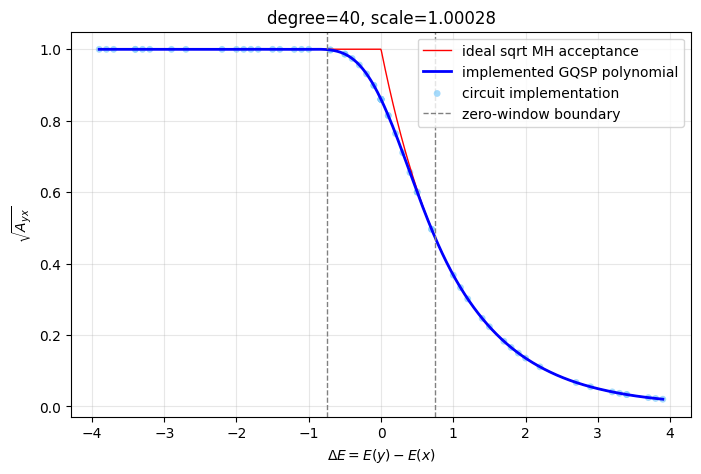

In [3]:
# 1. Smooth but less aggressive than Jackson.
# gate = plot_fully_phase_arithmetic(n, h, J, beta, eps_ops, a=np.inf, degree=20, poly_options=FullyPhaseArithmeticPolyOptions.hermite_window(0.25))
# 2. Same idea, larger ignored/smoothed window. Usually less ringing.
# gate = plot_fully_phase_arithmetic(n, h, J, beta, eps_ops, a=np.inf, degree=20, poly_options=FullyPhaseArithmeticPolyOptions.hermite_jackson_window(0.6))
# 3. Mask the bad region instead of smoothing it. Good to see what happens outside the window.
gate = plot_fully_phase_arithmetic(n, h, J, beta, eps_ops, a=np.inf, degree=40, poly_options=FullyPhaseArithmeticPolyOptions.masked_window(0.75))
# 4. Mask + Jackson. More damping, but can flatten/round the curve too much.
# gate = plot_fully_phase_arithmetic(n, h, J, beta, eps_ops, a=np.inf, degree=20, poly_options=FullyPhaseArithmeticPolyOptions.masked_jackson_window(0.4))
# 6. Higher degree + Hermite + Jackson. Usually the cleanest visually.
# gate = plot_fully_phase_arithmetic(n, h, J, beta, eps_ops, a=np.inf, degree=40, poly_options=FullyPhaseArithmeticPolyOptions.hermite_jackson_window(0.4))
# 7. Smooth generalized Glauber, close-ish to MH but no kink.
# gate = plot_fully_phase_arithmetic(n, h, J, beta, eps_ops, a=4.0, degree=20, poly_options=FullyPhaseArithmeticPolyOptions.projection())

Note that inside the window the polynomial can smooth out the kink at zero in different ways. We can also show how the error grows with the parameter $\kappa=\beta\alpha/2$. We estimate the maximum absolute error outside the window $w$. Here $w$ is a small constant that does not grow with $n$, and the approximation error $\varepsilon_\text{ops}$ is a small constant.

We compare the effect of choosing a fixed degree independent of $\kappa$ (red line) and choosing a degree that grows with $\kappa$ and $n$ according to the rule explained above (blue line). The blue line depends on $B\sim 2n$, avoiding the unnecessary overhead of the conservative LCU scale $\alpha\sim n^{3/2}$.

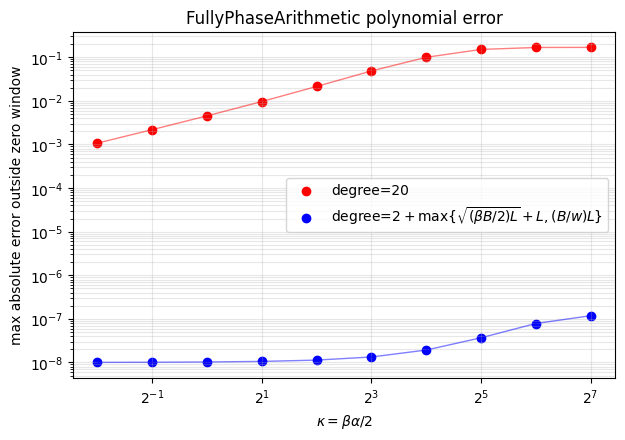

In [4]:
res = plot_error_fully_phase_arithmetic(n, h, J, eps_ops=1e-5, a=np.inf, poly_options=FullyPhaseArithmeticPolyOptions.masked_window(0.5))

Above, the degree $d$ is chosen using the convenient parameter $B\sim 2n$ instead of the conservative LCU scale $\alpha\sim (2/\sqrt{\pi})n^{3/2}$. This is sufficient to get close to the desired error. A further buffer can be added by multiplying the degree by a safety constant $c>1$.

To check that the relevant spectral range grows much more slowly than $\alpha$ on average, we test the claim on random instances; see `1_sherrington_kirkpatrick.ipynb`. There, the 1-norm upper bound is compared with the expected energy scale: the former grows as $\frac{1}{\sqrt{\pi}}n^{3/2}$, while the latter grows as $n$. The corresponding energy-difference scales are twice these quantities.